Libraries imported successfully.
 Model loaded successfully from:
  ./Results/Trained_Models/RS42_consensus_n7_fast_aggr_False_DecisionTree_model.pkl

 Training data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n7_fast_aggr_False_train_data.parquet (shape: (53, 8))
 Test data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n7_fast_aggr_False_test_data.parquet (shape: (10, 8))
 Predictions made for both training and test sets.
  - Training predictions shape: (53,)
  - Test predictions shape: (10,)
╔═════════════════╦═════════════╦═════════════╗
║   Metric        ║  Train Set  ║   Test Set  ║
╠═════════════════╬═════════════╬═════════════╣
║ R² (R-squared)  ║   0.7116    ║   0.6522    ║
║ RMSE            ║   16.86      ║   18.35      ║
╚═════════════════╩═════════════╩═════════════╝


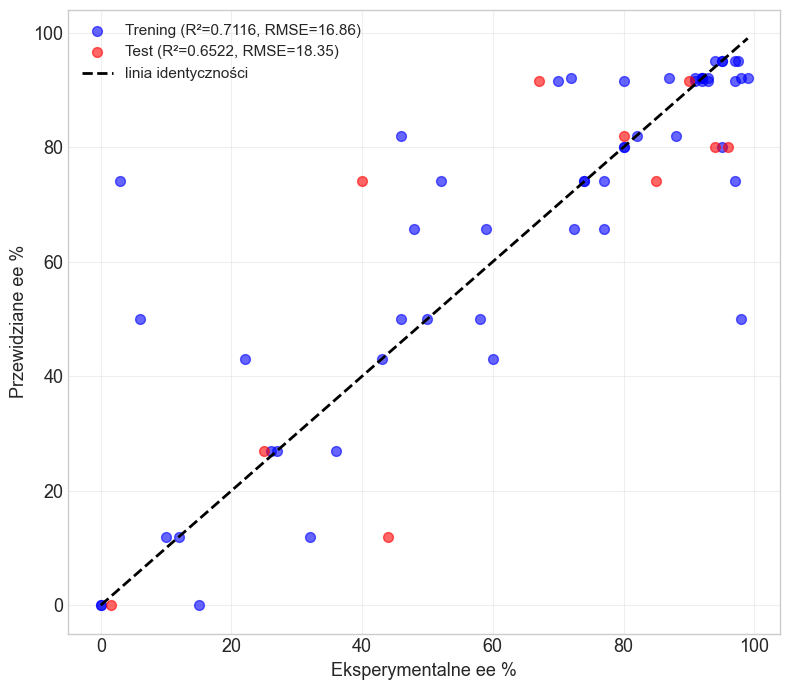

 Combined plot generated successfully


In [1]:
# # QSPR Model Verification and Visualization
# 
# This notebook loads a previously trained model and its corresponding training/test data to:
# 1.  Verify the model's performance by recalculating key metrics.
# 2.  Generate a publication-quality scatter plot of observed vs. predicted values.
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Libraries imported successfully.")

# ===================================================================
# CONFIGURATION: Specify file paths
# ===================================================================
model_path = './Results/Trained_Models/RS42_consensus_n7_fast_aggr_False_DecisionTree_model.pkl'
train_data_path = './Results/Selected_Data/RS42_consensus_n7_fast_aggr_False_train_data.parquet'
test_data_path = './Results/Selected_Data/RS42_consensus_n7_fast_aggr_False_test_data.parquet'

# Load the model
model = joblib.load(model_path)
print(f" Model loaded successfully from:\n  {model_path}\n")

# Load the datasets
train_df = pd.read_parquet(train_data_path)
test_df = pd.read_parquet(test_data_path)
print(f" Training data loaded successfully from:\n  {train_data_path} (shape: {train_df.shape})")
print(f" Test data loaded successfully from:\n  {test_data_path} (shape: {test_df.shape})")
# ## Prepare Data and Make Predictions

# ===================================================================
# DATA PREPARATION AND PREDICTION
# ===================================================================
# Separate features (X) and target (y)
TARGET_COLUMN = 'ee'

X_train = train_df.drop(columns=[TARGET_COLUMN])
X_train = X_train[list(train_df.iloc[:, :-1].columns)]
y_train = train_df[TARGET_COLUMN]

X_test = test_df.drop(columns=[TARGET_COLUMN])
X_test = X_test[list(train_df.iloc[:, :-1].columns)]
y_test = test_df[TARGET_COLUMN]

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(" Predictions made for both training and test sets.")
print(f"  - Training predictions shape: {y_pred_train.shape}")
print(f"  - Test predictions shape: {y_pred_test.shape}")

# ===================================================================
# PERFORMANCE VERIFICATION
# ===================================================================
# Calculate metrics for the training set
train_r2 = r2_score(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

# Calculate metrics for the test set
test_r2 = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("╔═════════════════╦═════════════╦═════════════╗")
print("║   Metric        ║  Train Set  ║   Test Set  ║")
print("╠═════════════════╬═════════════╬═════════════╣")
print(f"║ R² (R-squared)  ║   {train_r2:.4f}    ║   {test_r2:.4f}    ║")
print(f"║ RMSE            ║   {train_rmse:.2f}      ║   {test_rmse:.2f}      ║")
print("╚═════════════════╩═════════════╩═════════════╝")

# ===================================================================
# PLOT OBSERVED VS. PREDICTED (COMBINED) AND SAVE FIGURE
# ===================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Plot both training and test data on the same axes
ax.scatter(y_train, y_pred_train, c='blue', alpha=0.6, s=50, label=f'Trening (R²={train_r2:.4f}, RMSE={train_rmse:.2f})')
ax.scatter(y_test, y_pred_test, c='red', alpha=0.6, s=50, label=f'Test (R²={test_r2:.4f}, RMSE={test_rmse:.2f})')

# Identity line
all_y = np.concatenate([y_train, y_test])
all_pred = np.concatenate([y_pred_train, y_pred_test])
min_val = min(all_y.min(), all_pred.min())
max_val = max(all_y.max(), all_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='linia identyczności')

# Labels and title
ax.tick_params(axis='both', which='major', labelsize=13)
ax.set_xlabel('Eksperymentalne ee %', fontsize=13)
ax.set_ylabel('Przewidziane ee %', fontsize=13)
#ax.set_title('Model Performance: Training and Test Sets', fontsize=15, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('model_performance_combined.svg', format='svg', dpi=300, bbox_inches='tight')

plt.show()

print(" Combined plot generated successfully")

In [2]:
model[2]

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'absolute_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [3]:
## Validation set

import sys
import pandas as pd
import numpy as np
import pickle
import warnings
from pathlib import Path
from datetime import datetime

# Add module path for imports
module_path = Path('.').parent / 'module'  # Adjust if needed
if module_path.exists():
    sys.path.insert(0, str(module_path))
    print(f" Module path added: {module_path}")
else:
    print(f" Module path not found: {module_path}")
    print(f"  Current directory: {Path('.').resolve()}")
    print(f"  Please ensure calculate_descriptors.py is in a 'module' subdirectory")

warnings.filterwarnings('ignore')

# Import from your QSPR module
try:
    from calculate_descriptors import prepare_data
    print(" Successfully imported from calculate_descriptors.py")
except ImportError as e:
    print(f" Error importing from models_creation.py: {e}")
    raise

print("\n All imports successful")

 Module path added: module

╔════════════════════════════════════════════════════════════════════════════╗
║                                                                            ║
║                calculate_descriptors.py MODULE READY                       ║
║                                                                            ║
║         Import this module in your QSPR analysis scripts                   ║
║         Location: module/calculate_descriptors.py                          ║
║                                                                            ║
╚════════════════════════════════════════════════════════════════════════════╝
    
 Successfully imported from calculate_descriptors.py

 All imports successful


In [4]:
CONFIG = {
    # Data file
    'data': './Data/Exp_verification_III_modyfikacja_10struktur.xlsx',
    'target_col': 'ee',
    'name': 'validation_set',
    'mode': 'validation',
    'output_dir': './Data/'
}

In [5]:
# ============================================================================
# SECTION 3: LOAD DATA & CALCULATE ALL DESCRIPTORS
# ============================================================================

print('\n' + "█"*75)
print("█" + " STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS ".center(73) + "█")
print("█"*75)

print(f"\nLoading data from: {CONFIG['data']}")
print(f"Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic")
print(f"This may take 5-15 minutes depending on dataset size...")

try:
    # Calculate ALL descriptors (full set)
    data = prepare_data(
        CONFIG['data'],
        CONFIG['target_col'],
        CONFIG['name'],
        CONFIG['mode'],
        CONFIG['output_dir'],
       
    )
    
    print(f"\n Data loaded and ALL descriptors calculated")
    print(f"  Total samples: {data.shape[0]}")
    print(f"  Total features: {data.shape[1]-1} (+ target)")
    print(f"  Target range: [{data[CONFIG['target_col']].min():.1f}, {data[CONFIG['target_col']].max():.1f}]")
    print(f"  Target mean: {data[CONFIG['target_col']].mean():.2f}")
    print(f"  Target std: {data[CONFIG['target_col']].std():.2f}")
    
except Exception as e:
    print(f"\n Error loading data: {e}")
    print(f"\n  Try these solutions:")
    print(f"  1. Check if {CONFIG['data']} exists")
    print(f"  2. Verify path is correct (relative or absolute)")
    print(f"  3. Check if models_creation.py is accessible")
    raise


███████████████████████████████████████████████████████████████████████████
█              STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS              █
███████████████████████████████████████████████████████████████████████████

Loading data from: ./Data/Exp_verification_III_modyfikacja_10struktur.xlsx
Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic
This may take 5-15 minutes depending on dataset size...

LOADING DATA FOR UNIFIED DESCRIPTOR CALCULATION
  DESCRIPTOR PIPELINE:
 Mordred: True
 Morgan FP: True
 Sterimol + Electronic: True
 ChemBERTa: False
 CircuS: True
 ChyLine: True

---------------------------------------------------------------------------
Calculating/Cleaning descriptors ...
---------------------------------------------------------------------------
SUCCESS: Loaded CLEANED descriptors from Data\molecular_descriptors_cleaned_validation_set_.parquet
Shape: (10, 4110)
Returning: full descriptor set

 Data loaded and ALL descriptors 

In [6]:
X_train.columns

Index(['IC1', 'GATS6are', 'ATSC1c', 'CIC1', 'GATS4d', 'PEOE_VSA6', 'SMR_VSA6'], dtype='object')

In [7]:
data[list(X_train.columns)]

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6
0,2.998636,1.745564,-0.280241,2.524926,0.687612,75.378168,0.000000
1,3.030130,1.144754,-0.093586,2.827851,0.757041,87.501249,0.000000
2,2.653997,1.516895,-0.085387,2.869565,1.036497,72.796405,0.000000
3,3.030130,1.297944,-0.094609,2.827851,0.745395,93.577269,0.000000
4,2.694069,1.349328,-0.225428,3.060819,0.637226,87.510902,0.000000
5,2.318135,1.291567,-0.214232,3.463224,1.038387,97.071526,0.000000
6,2.919148,1.154677,-0.177539,2.987743,0.766020,93.577269,7.109798
7,2.634762,1.453940,-0.169340,2.950201,1.035315,78.872425,7.109798
8,3.047159,1.303744,-0.168693,2.707728,0.696532,75.368515,0.000000
9,2.680262,1.841973,-0.160494,2.712055,0.940182,60.663671,0.000000


In [8]:
y_pred_val = model.predict(data[list(X_train.columns)])

In [9]:
y_pred_val

array([65.75, 65.75, 50.  , 65.75, 92.  , 80.  , 65.75, 91.5 , 65.75,
       74.  ])

In [10]:
y_pred_val[0]

np.float64(65.75)

In [11]:
data['ee']

0    66.0
1    73.0
2    27.0
3    56.0
4    92.0
5    79.5
6    47.0
7    88.0
8    65.0
9    43.5
Name: ee, dtype: float64

In [12]:
# Calculate metrics for the validation set
val_r2 = r2_score(data['ee'], y_pred_val)
val_rmse = np.sqrt(mean_squared_error(data['ee'], y_pred_val))

In [13]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  Validation Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {val_r2:.4f}                  ║")
print(f"║ RMSE            ║   {val_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

╔═════════════════╦═══════════════════════════╗
║   Metric        ║  Validation Set           ║
╠═════════════════╬═══════════════════════════╣
║ R² (R-squared)  ║   0.4849                  ║
║ RMSE            ║   14.04                   ║
╚═════════════════╩═══════════════════════════╝


In [14]:


for x in range(len(y_pred_val)):

    print("Observed ee: " + str(data['ee'][x]) + '   ' + "Predicted ee: " +str(y_pred_val[x]))

Observed ee: 66.0   Predicted ee: 65.75
Observed ee: 73.0   Predicted ee: 65.75
Observed ee: 27.0   Predicted ee: 50.0
Observed ee: 56.0   Predicted ee: 65.75
Observed ee: 92.0   Predicted ee: 92.0
Observed ee: 79.5   Predicted ee: 80.0
Observed ee: 47.0   Predicted ee: 65.75
Observed ee: 88.0   Predicted ee: 91.5
Observed ee: 65.0   Predicted ee: 65.75
Observed ee: 43.5   Predicted ee: 74.0


In [15]:
validation_data = './Data/Exp_verification_III_modyfikacja_10struktur.xlsx'


# Load the datasets
val_df = pd.read_excel(validation_data)
val_df.head(1)

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0


Observed ee: 66.0   Predicted ee: 65.75


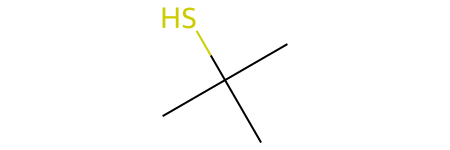

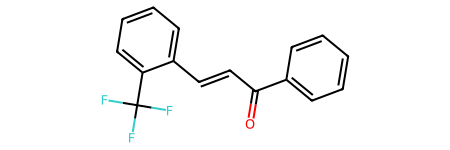

Observed ee: 73.0   Predicted ee: 65.75


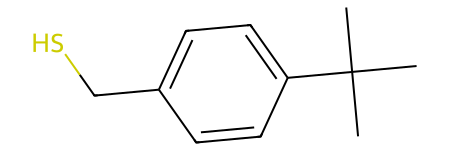

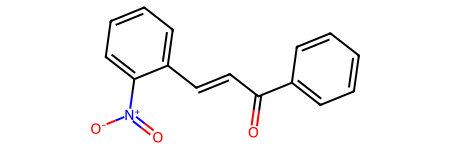

Observed ee: 27.0   Predicted ee: 50.0


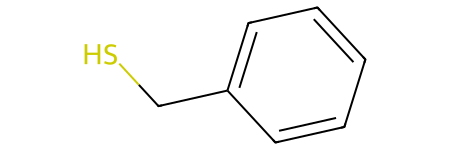

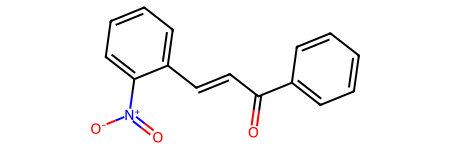

Observed ee: 56.0   Predicted ee: 65.75


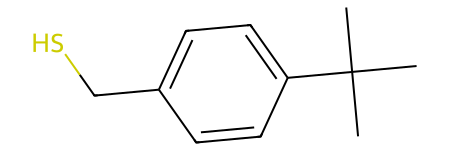

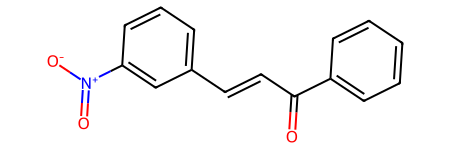

Observed ee: 92.0   Predicted ee: 92.0


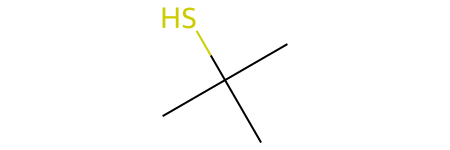

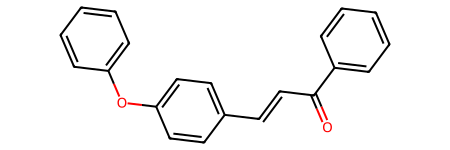

Observed ee: 79.5   Predicted ee: 80.0


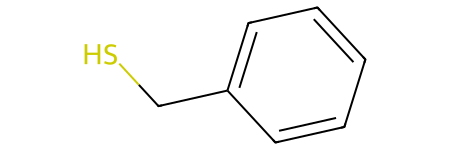

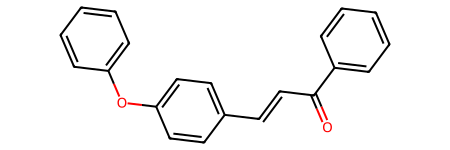

Observed ee: 47.0   Predicted ee: 65.75


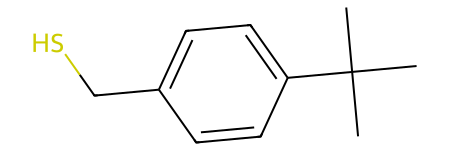

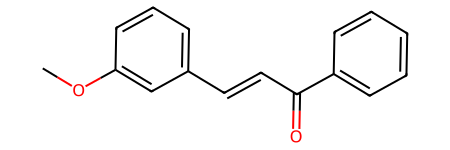

Observed ee: 88.0   Predicted ee: 91.5


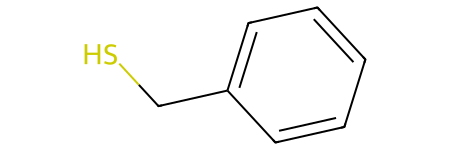

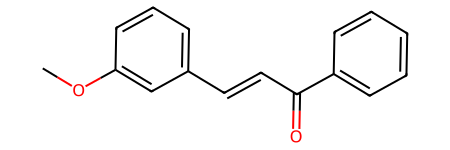

Observed ee: 65.0   Predicted ee: 65.75


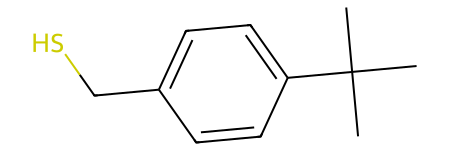

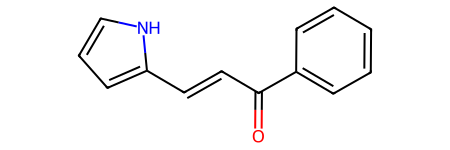

Observed ee: 43.5   Predicted ee: 74.0


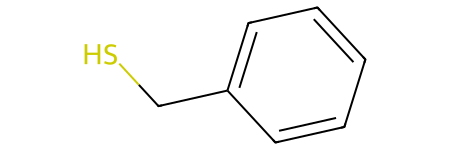

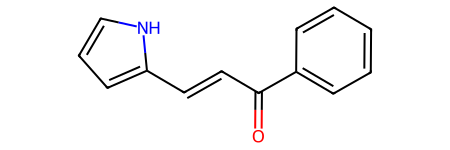

In [16]:

from rdkit import Chem
from IPython.display import display

for x in range(len(y_pred_val)):
    print("Observed ee: " + str(data['ee'][x]) + '   ' + "Predicted ee: " + str(y_pred_val[x]))
    mol = Chem.MolFromSmiles(val_df['SMILES_tiol'][x])
    display(mol)
    mol = Chem.MolFromSmiles(val_df['SMILES_chalkon'][x])
    display(mol)


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial import Delaunay
import warnings
warnings.filterwarnings('ignore')


In [19]:
CONFIG = {
    # Data file
    'data': './Data/Exp_verification_III_modyfikacja_10struktur.xlsx',
    'target_col': 'ee',
    'name': 'validation_set',
    'mode': 'validation',
    'output_dir': './Data/'
}

In [20]:
# ============================================================================
# SECTION 3: LOAD DATA & CALCULATE ALL DESCRIPTORS
# ============================================================================

print('\n' + "█"*75)
print("█" + " STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS ".center(73) + "█")
print("█"*75)

print(f"\nLoading data from: {CONFIG['data']}")
print(f"Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic")
print(f"This may take 5-15 minutes depending on dataset size...")

try:
    # Calculate ALL descriptors (full set)
    data = prepare_data(
        CONFIG['data'],
        CONFIG['target_col'],
        CONFIG['name'],
        CONFIG['mode'],
        CONFIG['output_dir'],
       
    )
    
    print(f"\n Data loaded and ALL descriptors calculated")
    print(f"  Total samples: {data.shape[0]}")
    print(f"  Total features: {data.shape[1]-1} (+ target)")
    print(f"  Target range: [{data[CONFIG['target_col']].min():.1f}, {data[CONFIG['target_col']].max():.1f}]")
    print(f"  Target mean: {data[CONFIG['target_col']].mean():.2f}")
    print(f"  Target std: {data[CONFIG['target_col']].std():.2f}")
    
except Exception as e:
    print(f"\n Error loading data: {e}")
    print(f"\n  Try these solutions:")
    print(f"  1. Check if {CONFIG['data']} exists")
    print(f"  2. Verify path is correct (relative or absolute)")
    print(f"  3. Check if models_creation.py is accessible")
    raise


███████████████████████████████████████████████████████████████████████████
█              STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS              █
███████████████████████████████████████████████████████████████████████████

Loading data from: ./Data/Exp_verification_III_modyfikacja_10struktur.xlsx
Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic
This may take 5-15 minutes depending on dataset size...

LOADING DATA FOR UNIFIED DESCRIPTOR CALCULATION
  DESCRIPTOR PIPELINE:
 Mordred: True
 Morgan FP: True
 Sterimol + Electronic: True
 ChemBERTa: False
 CircuS: True
 ChyLine: True

---------------------------------------------------------------------------
Calculating/Cleaning descriptors ...
---------------------------------------------------------------------------
SUCCESS: Loaded CLEANED descriptors from Data\molecular_descriptors_cleaned_validation_set_.parquet
Shape: (10, 4110)
Returning: full descriptor set

 Data loaded and ALL descriptors 

In [21]:
data[list(X_train.columns)]

,IC1,GATS6are,ATSC1c,CIC1,GATS4d,PEOE_VSA6,SMR_VSA6
0,2.998636,1.745564,-0.280241,2.524926,0.687612,75.378168,0.000000
1,3.030130,1.144754,-0.093586,2.827851,0.757041,87.501249,0.000000
2,2.653997,1.516895,-0.085387,2.869565,1.036497,72.796405,0.000000
3,3.030130,1.297944,-0.094609,2.827851,0.745395,93.577269,0.000000
4,2.694069,1.349328,-0.225428,3.060819,0.637226,87.510902,0.000000
5,2.318135,1.291567,-0.214232,3.463224,1.038387,97.071526,0.000000
6,2.919148,1.154677,-0.177539,2.987743,0.766020,93.577269,7.109798
7,2.634762,1.453940,-0.169340,2.950201,1.035315,78.872425,7.109798
8,3.047159,1.303744,-0.168693,2.707728,0.696532,75.368515,0.000000
9,2.680262,1.841973,-0.160494,2.712055,0.940182,60.663671,0.000000


In [22]:
y_pred_exp = model.predict(data[list(X_train.columns)])

In [23]:
# Calculate metrics for the validation set
exp_r2 = r2_score(data['ee'], y_pred_exp)
exp_rmse = np.sqrt(mean_squared_error(data['ee'], y_pred_exp))

In [24]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  Validation Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {exp_r2:.4f}                  ║")
print(f"║ RMSE            ║   {exp_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

╔═════════════════╦═══════════════════════════╗
║   Metric        ║  Validation Set           ║
╠═════════════════╬═══════════════════════════╣
║ R² (R-squared)  ║   0.4849                  ║
║ RMSE            ║   14.04                   ║
╚═════════════════╩═══════════════════════════╝


In [25]:


for x in range(len(y_pred_exp)):

    print("Observed ee: " + str(data['ee'][x]) + '   ' + "Predicted ee: " +str(y_pred_exp[x]))

Observed ee: 66.0   Predicted ee: 65.75
Observed ee: 73.0   Predicted ee: 65.75
Observed ee: 27.0   Predicted ee: 50.0
Observed ee: 56.0   Predicted ee: 65.75
Observed ee: 92.0   Predicted ee: 92.0
Observed ee: 79.5   Predicted ee: 80.0
Observed ee: 47.0   Predicted ee: 65.75
Observed ee: 88.0   Predicted ee: 91.5
Observed ee: 65.0   Predicted ee: 65.75
Observed ee: 43.5   Predicted ee: 74.0


In [26]:
exp_data = './Data/Exp_verification_III_modyfikacja_10struktur.xlsx'


# Load the datasets
exp_df = pd.read_excel(exp_data)
exp_df.head(1)

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def analyze_applicability_heuristic(X_train, X_val, X_test, heuristic_threshold=0.1):
    """
    Analyzes Applicability Domain with Convex Hull and Distance Heuristic.
    Returns dictionaries containing processed DataFrames for Experimental (Val) and Test sets,
    printing indices of molecules outside the safe domain.
    """
    
    # 1. Preprocessing & PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test) 
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 2. Convex Hull (Delaunay) on Training Data
    tri = Delaunay(X_train_pca)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Helper: Distance to Hull Calculation
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        # A. Distance to Hull (Geometric approach)
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0,1], [1,2], [2,0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        r_d_hull = min(dist_vertices, min_edge_dist)
        
        # B. Distance to Geometric Center (Centroid)
        r_geometrical_center = np.linalg.norm(point - centroid)
        
        # C. Heuristic Ratio
        rel_distance = r_d_hull / r_geometrical_center if r_geometrical_center > 1e-9 else 0
        
        return rel_distance

    # 4. Universal Function to Process Any Dataset
    def process_dataset(X_data, X_pca_data, dataset_name="Data"):
        if isinstance(X_data, pd.DataFrame):
            df_out = X_data.copy()
            
            indices = X_data.index.tolist()
        else:
            df_out = pd.DataFrame(X_data)
            indices = list(range(len(X_data)))
            
        is_inside = tri.find_simplex(X_pca_data) >= 0
        
        status_list = []
        rel_dist_list = []
        
        for i in range(len(X_pca_data)):
            if is_inside[i]:
                status_list.append('Inside Hull')
                rel_dist_list.append(0.0) 
            else:
                rel_dist = get_hull_distance_info(X_pca_data[i], tri, X_train_pca, centroid_train)
                rel_dist_list.append(rel_dist)
                
                if rel_dist < heuristic_threshold:
                    status_list.append('Extended Domain')
                else:
                    status_list.append('Out of Domain')
        
        df_out['AD_Status'] = status_list
        df_out['Rel_Distance'] = rel_dist_list
        # Dodajemy kolumnę pomocniczą z indeksem do łatwego dostępu
        df_out['Original_Index'] = indices
        
        return df_out, np.array(status_list)

    # 5. Apply Logic
    print("Processing Experimental Data...")
    X_val_df, val_statuses = process_dataset(X_val, X_val_pca, "Experimental")
    
    print("Processing Test Data...")
    X_test_df, test_statuses = process_dataset(X_test, X_test_pca, "Test")

    # 6. PLOTTING
    plt.figure(figsize=(12, 9))
    
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, color='gray', alpha=0.4)
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='blue', alpha=0.3, label='Training Data')
    plt.scatter(centroid_train[0], centroid_train[1], c='black', marker='+', s=200, label='Centroid')

    style_map = {
        'Inside Hull':     {'c': 'green', 'm': 'o', 'alpha': 0.6},
        'Extended Domain': {'c': 'orange', 'm': 'D', 'alpha': 0.8},
        'Out of Domain':   {'c': 'red',   'm': 'X', 'alpha': 0.9}
    }

    # Helper function to plot and annotate
    def plot_subset(df, pca_data, label_prefix, marker_style):
        for status in style_map:
            mask = df['AD_Status'] == status
            if mask.any():
                plt.scatter(pca_data[mask, 0], pca_data[mask, 1], 
                            c=style_map[status]['c'], marker=marker_style, s=60, edgecolors='black',
                            label=f'{label_prefix}: {status}')
                
                # Annotation for non-Inside points
                if status in ['Out of Domain', 'Extended Domain']:
                    idxs = np.where(mask)[0]
                    for idx in idxs:
                        dist = df.iloc[idx]['Rel_Distance']
                        mol_idx = df.iloc[idx]['Original_Index']
                        
                        #"Index: Distance annotation format"
                        label_text = f"#{mol_idx}\n{dist:.2f}"
                        
                        plt.annotate(label_text, 
                                     (pca_data[idx, 0], pca_data[idx, 1]),
                                     xytext=(5, 5), textcoords='offset points', 
                                     fontsize=8, fontweight='bold', color='black',
                                     bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

    plot_subset(X_val_df, X_val_pca, "Exp", 's')
    plot_subset(X_test_df, X_test_pca, "Test", 'P')

    plt.title(f'Applicability Domain (Threshold={heuristic_threshold})')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('AD_heuristic_plot_EXP.svg', dpi=300)
    plt.show()

    # 7. Summary Print with Indices
    def print_outliers(df, name):
        print(f"\n--- Detailed Report: {name} Set ---")
        counts = df['AD_Status'].value_counts()
        print(counts)
        
        for status in ['Extended Domain', 'Out of Domain']:
            subset = df[df['AD_Status'] == status]
            if not subset.empty:
                print(f"\n[{status}] Molecules (Index -> Rel_Distance):")
                for _, row in subset.iterrows():
                    print(f"  - Index {row['Original_Index']}: {row['Rel_Distance']:.4f}")
            else:
                print(f"\n[{status}]: None")

    print_outliers(X_val_df, "Experimental")
    print_outliers(X_test_df, "Test")

    return {
        'exp_results_df': X_val_df,
        'test_results_df': X_test_df
    }


In [32]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.spatial import Delaunay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


from pathlib import Path

OUTPUT_DIR = Path(
    r"C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml"
    r"\thia-Michael_regression\third_split\Kfold\substrate"
    r"\no_chemberta_Kfold_Review_1\Results\ReviewerValidation"
)

AD_OUTPUT_DIR = OUTPUT_DIR / "ApplicabilityDomain"
AD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"AD output directory: {AD_OUTPUT_DIR}")

mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 8.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.linewidth": 1.1,
})


def analyze_applicability_heuristic(
    X_train,
    X_val,
    X_test,
    heuristic_threshold=0.1,
    output_dir=AD_OUTPUT_DIR,
    figure_name="Fig_S_AD_heuristic",
):
    """
    PCA/Delaunay-based applicability-domain visualization.

    The current geometric heuristic is retained.
    Unique identifiers are assigned to validation and test observations:
    EXP-01, EXP-02, ... and TEST-01, TEST-02, ...

    Only Extended Domain and Out of Domain points are annotated.
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # 1. Standardization and PCA fitted exclusively on training descriptors.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # 2. Delaunay triangulation and training-set centroid in PCA space.
    tri = Delaunay(X_train_pca)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Retain your current distance heuristic.
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        dist_vertices = np.min(
            np.linalg.norm(X_train_pca - point, axis=1)
        )

        min_edge_dist = np.inf

        for simplex in tri.simplices:
            for edge in [[0, 1], [1, 2], [2, 0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]

                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)

                if edge_len2 != 0:
                    projection = np.dot(point_vec, edge_vec) / edge_len2
                    projection = np.clip(projection, 0, 1)
                    closest = p1 + projection * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(
                        min_edge_dist,
                        np.linalg.norm(point - p1),
                    )

        r_d_hull = min(dist_vertices, min_edge_dist)
        r_geometrical_center = np.linalg.norm(point - centroid)

        return (
            r_d_hull / r_geometrical_center
            if r_geometrical_center > 1e-9
            else 0.0
        )

    # 4. Process validation or development-comparison dataset.
    def process_dataset(
        X_data,
        X_pca_data,
        dataset_name,
        id_prefix,
    ):
        if isinstance(X_data, pd.DataFrame):
            df_out = X_data.copy()
            original_indices = X_data.index.astype(str).tolist()
        else:
            df_out = pd.DataFrame(X_data)
            original_indices = [str(i) for i in range(len(X_data))]

        is_inside = tri.find_simplex(X_pca_data) >= 0

        status_list = []
        relative_distance_list = []

        for i, point in enumerate(X_pca_data):
            if is_inside[i]:
                status_list.append("Inside Hull")
                relative_distance_list.append(0.0)
            else:
                relative_distance = get_hull_distance_info(
                    point,
                    tri,
                    X_train_pca,
                    centroid_train,
                )

                relative_distance_list.append(relative_distance)

                if relative_distance < heuristic_threshold:
                    status_list.append("Extended Domain")
                else:
                    status_list.append("Out of Domain")

        df_out["AD_ID"] = [
            f"{id_prefix}-{i + 1:02d}"
            for i in range(len(df_out))
        ]
        df_out["Original_Index"] = original_indices
        df_out["AD_Status"] = status_list
        df_out["Rel_Distance"] = relative_distance_list
        df_out["PC1"] = X_pca_data[:, 0]
        df_out["PC2"] = X_pca_data[:, 1]

        return df_out, np.asarray(status_list)

    print("Processing experimental/prospective validation data...")

    X_val_df, val_statuses = process_dataset(
        X_data=X_val,
        X_pca_data=X_val_pca,
        dataset_name="Experimental",
        id_prefix="EXP",
    )

    print("Processing development comparison/test data...")

    X_test_df, test_statuses = process_dataset(
        X_data=X_test,
        X_pca_data=X_test_pca,
        dataset_name="Test",
        id_prefix="TEST",
    )

    # 5. Publication-oriented visualization.
    fig, ax = plt.subplots(figsize=(9.0, 7.0))

    ax.triplot(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        tri.simplices,
        color="#A6A6A6",
        alpha=0.30,
        linewidth=0.7,
        zorder=1,
    )

    ax.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        color="#BDBDBD",
        edgecolor="white",
        linewidth=0.4,
        alpha=0.90,
        s=42,
        label="Training set",
        zorder=2,
    )

    ax.scatter(
        centroid_train[0],
        centroid_train[1],
        color="#1A1A1A",
        marker="+",
        s=145,
        linewidth=2.0,
        label="Training centroid",
        zorder=5,
    )

    style_map = {
        "Inside Hull": {
            "color": "#2E8B57",
            "marker": "o",
            "alpha": 0.75,
        },
        "Extended Domain": {
            "color": "#E69F00",
            "marker": "D",
            "alpha": 0.95,
        },
        "Out of Domain": {
            "color": "#C62828",
            "marker": "X",
            "alpha": 0.95,
        },
    }

    def plot_subset(df, label_prefix, marker_style):
        for status, style in style_map.items():
            mask = df["AD_Status"] == status

            if not mask.any():
                continue

            ax.scatter(
                df.loc[mask, "PC1"],
                df.loc[mask, "PC2"],
                color=style["color"],
                marker=marker_style,
                s=82,
                alpha=style["alpha"],
                edgecolor="black",
                linewidth=0.7,
                label=f"{label_prefix}: {status}",
                zorder=6,
            )

            # Annotate only points requiring structural interpretation.
            if status in ["Extended Domain", "Out of Domain"]:
                for _, row in df.loc[mask].iterrows():
                    label_text = (
                        f"{row['AD_ID']}\n"
                        f"{row['Rel_Distance']:.2f}"
                    )

                    ax.annotate(
                        label_text,
                        (row["PC1"], row["PC2"]),
                        xytext=(6, 6),
                        textcoords="offset points",
                        fontsize=8,
                        fontweight="bold",
                        color="#1A1A1A",
                        bbox=dict(
                            boxstyle="round,pad=0.20",
                            facecolor="white",
                            edgecolor="#A6A6A6",
                            linewidth=0.6,
                            alpha=0.92,
                        ),
                        zorder=8,
                    )

    plot_subset(
        X_val_df,
        label_prefix="Experimental",
        marker_style="s",
    )

    plot_subset(
        X_test_df,
        label_prefix="Comparison",
        marker_style="P",
    )

    ax.set_title(
        f"PCA-based applicability-domain visualization "
        f"(threshold = {heuristic_threshold:.2f})",
        fontweight="bold",
        pad=12,
    )

    ax.set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
    )

    ax.set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
    )

    ax.grid(True, color="#E6E6E6", linewidth=0.7, zorder=0)
    ax.tick_params(direction="out", width=1.0, length=4.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    handles, labels = ax.get_legend_handles_labels()
    unique_legend = dict(zip(labels, handles))

    ax.legend(
        unique_legend.values(),
        unique_legend.keys(),
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        frameon=False,
        fontsize=8.2,
    )

    fig.tight_layout()

    figure_base = output_dir / figure_name

    fig.savefig(
        figure_base.with_suffix(".pdf"),
        bbox_inches="tight",
    )

    fig.savefig(
        figure_base.with_suffix(".svg"),
        bbox_inches="tight",
    )

    fig.savefig(
        figure_base.with_suffix(".png"),
        dpi=600,
        bbox_inches="tight",
    )

    plt.show()

    # 6. Save complete tables for traceability.
    X_val_df.to_csv(
        output_dir / "AD_experimental_results.csv",
        index=True,
    )

    X_test_df.to_csv(
        output_dir / "AD_comparison_results.csv",
        index=True,
    )

    # 7. Compact printed summary.
    def print_outliers(df, name):
        print(f"\n--- {name}: AD status counts ---")
        display(df["AD_Status"].value_counts())

        outside_df = df.loc[
            df["AD_Status"].isin(
                ["Extended Domain", "Out of Domain"]
            ),
            [
                "AD_ID",
                "Original_Index",
                "AD_Status",
                "Rel_Distance",
            ],
        ].sort_values(
            ["AD_Status", "Rel_Distance"],
            ascending=[True, False],
        )

        if outside_df.empty:
            print("No Extended Domain or Out of Domain structures.")
        else:
            print(f"\n{name}: structures requiring interpretation")
            display(outside_df.round(4))

    print_outliers(X_val_df, "Experimental/prospective set")
    print_outliers(X_test_df, "Development comparison set")

    return {
        "exp_results_df": X_val_df,
        "test_results_df": X_test_df,
        "scaler": scaler,
        "pca": pca,
        "train_pca": X_train_pca,
        "val_pca": X_val_pca,
        "test_pca": X_test_pca,
    }

AD output directory: C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\thia-Michael_regression\third_split\Kfold\substrate\no_chemberta_Kfold_Review_1\Results\ReviewerValidation\ApplicabilityDomain


In [33]:
#result = analyze_applicability_heuristic(X_train, data[list(X_train.columns)], X_test, heuristic_threshold=0.1)

In [34]:
ad_results = analyze_applicability_heuristic(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    heuristic_threshold=0.10,
)

X_val_ad = ad_results["exp_results_df"].copy()
X_test_ad = ad_results["test_results_df"].copy()

NameError: name 'X_val' is not defined

In [33]:
fig = exp_df
fig['predicted_ee'] = y_pred_exp
fig.head()

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee,predicted_ee
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0,65.75
1,28,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,73.0,73.0,65.75
2,30,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=CC=C2)C3=CC=CC(...,27.0,27.0,50.00
3,31,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC([N+]([O-])=O)=C2,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,56.0,56.0,65.75
4,32,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC3=CC=CC=C3)C=C2,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=C(OC3=C...,92.0,92.0,92.00


In [34]:
fig['AD_Status'] = result['exp_results_df']['AD_Status']
fig.head()

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee,predicted_ee,AD_Status
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0,65.75,Inside Hull
1,28,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,73.0,73.0,65.75,Inside Hull
2,30,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=CC=C2)C3=CC=CC(...,27.0,27.0,50.00,Inside Hull
3,31,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC([N+]([O-])=O)=C2,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,56.0,56.0,65.75,Inside Hull
4,32,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC3=CC=CC=C3)C=C2,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=C(OC3=C...,92.0,92.0,92.00,Inside Hull


In [35]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

def draw_molgrid_with_results(df, 
                              smiles_col='SMILES_tiol',
                              smiles_col_2='SMILES_chalkon',
                              obs_col='ee', 
                              pred_col='predicted_ee',
                              hull_col='AD_Status',
                              n_per_row=4, 
                              max_mols=100, 
                              img_size=(400, 400)):

    combined_mols = []
    legends = []
    
    df_subset = df.head(max_mols)
    
    for idx, row in df_subset.iterrows():
        
        smi1 = str(row[smiles_col])
        smi2 = str(row[smiles_col_2])
        
        
        combined_smi = f"{smi1}.{smi2}"
        mol = Chem.MolFromSmiles(combined_smi)
        
        if mol is not None:
            combined_mols.append(mol)
            
            obs = row[obs_col]
            pred = row[pred_col]
            hull = row[hull_col]
            error = abs(obs - pred)

            label = f"Obs: {obs:.1f} | Pred: {pred:.1f} | Err: {error:.1f}\nAD: {hull}"
            legends.append(label)
        else:
            print(f"Błąd konwersji SMILES na indeksie {idx}")

    dopts = rdMolDraw2D.MolDrawOptions()
    dopts.legendFontSize = 24  
    dopts.padding = 0.05
    dopts.bondLineWidth = 3
    
    
    img = Draw.MolsToGridImage(
        combined_mols, 
        molsPerRow=n_per_row, 
        subImgSize=img_size, 
        legends=legends,
        useSVG=True,
        drawOptions=dopts
    )
    
    return img

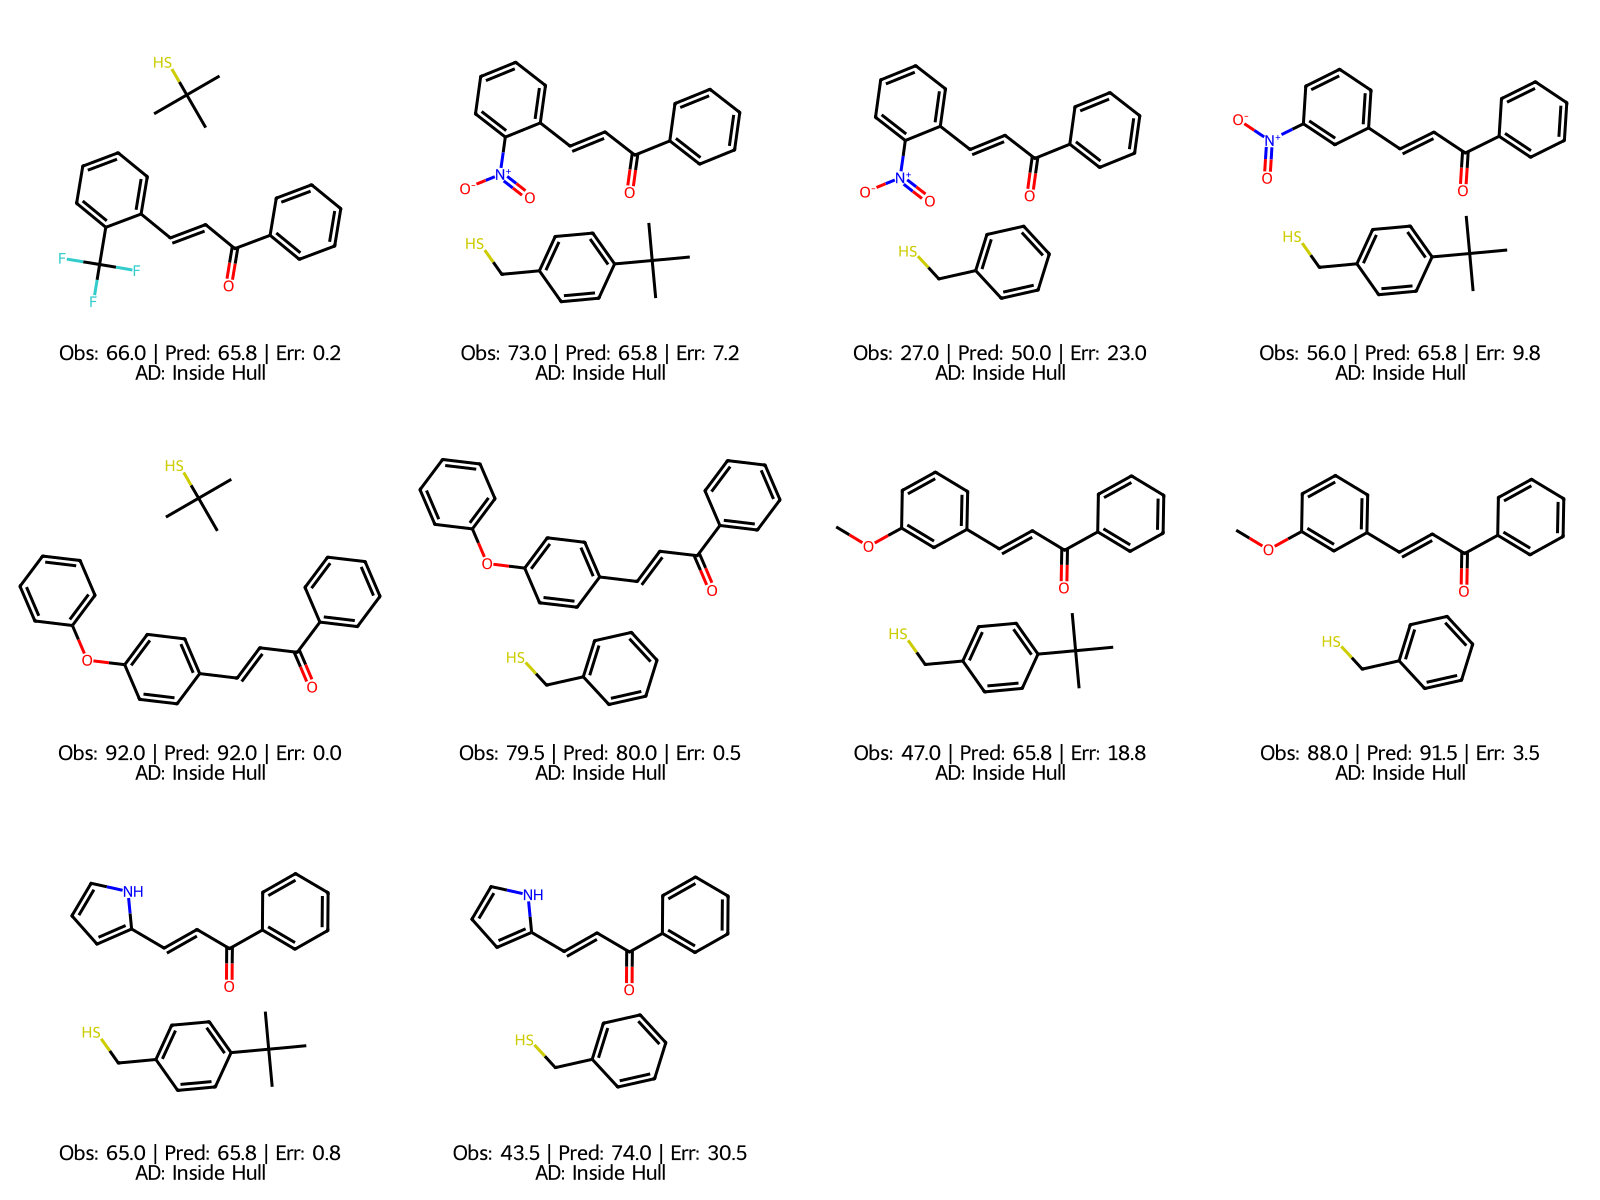

In [36]:
img = draw_molgrid_with_results(fig, max_mols=100)
display(img)

In [37]:
fig['AD_Status'] = result['exp_results_df']['AD_Status']
fig.head()

,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee,predicted_ee,AD_Status
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0,65.75,Inside Hull
1,28,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,73.0,73.0,65.75,Inside Hull
2,30,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=CC=C2)C3=CC=CC(...,27.0,27.0,50.00,Inside Hull
3,31,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC([N+]([O-])=O)=C2,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,56.0,56.0,65.75,Inside Hull
4,32,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC3=CC=CC=C3)C=C2,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=C(OC3=C...,92.0,92.0,92.00,Inside Hull


In [38]:
fig['ee'][fig['AD_Status'] == 'Inside Hull']

0    66.0
1    73.0
2    27.0
3    56.0
4    92.0
5    79.5
6    47.0
7    88.0
8    65.0
9    43.5
Name: ee, dtype: float64

In [39]:
# Calculate metrics for the validation set
exp_r2 = r2_score(fig['ee'][fig['AD_Status'] == 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] == 'Inside Hull'])
exp_rmse = np.sqrt(mean_squared_error(fig['ee'][fig['AD_Status'] == 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] == 'Inside Hull']))

In [40]:
len(fig['ee'][fig['AD_Status'] == 'Inside Hull'])

10

In [41]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  Inside Hull Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {exp_r2:.4f}                  ║")
print(f"║ RMSE            ║   {exp_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

╔═════════════════╦═══════════════════════════╗
║   Metric        ║  Inside Hull Set           ║
╠═════════════════╬═══════════════════════════╣
║ R² (R-squared)  ║   0.4849                  ║
║ RMSE            ║   14.04                   ║
╚═════════════════╩═══════════════════════════╝


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D


def draw_molgrid_with_results(
    df,
    smiles_col="SMILES_tiol",
    smiles_col_2="SMILES_chalkon",
    obs_col="ee",
    pred_col="predicted_ee",
    hull_col="AD_Status",
    ad_id_col="AD_ID",
    distance_col="Rel_Distance",
    n_per_row=3,
    max_mols=100,
    img_size=(430, 360),
):
    """
    Draws paired thiol + chalcone structures and adds AD identifiers.

    The input dataframe should already contain:
    AD_ID, AD_Status, Rel_Distance, observed ee, predicted ee,
    SMILES_tiol, and SMILES_chalkon.
    """

    combined_mols = []
    legends = []

    status_order = {
        "Out of Domain": 0,
        "Extended Domain": 1,
        "Inside Hull": 2,
    }

    df_subset = df.copy()

    df_subset["_status_order"] = df_subset[hull_col].map(
        status_order
    )

    df_subset = df_subset.sort_values(
        ["_status_order", distance_col],
        ascending=[True, False],
    ).head(max_mols)

    for dataframe_index, row in df_subset.iterrows():
        thiol_smiles = str(row[smiles_col])
        chalcone_smiles = str(row[smiles_col_2])

        combined_smiles = f"{thiol_smiles}.{chalcone_smiles}"
        mol = Chem.MolFromSmiles(combined_smiles)

        if mol is None:
            print(
                "SMILES conversion error for "
                f"{row.get(ad_id_col, dataframe_index)}"
            )
            continue

        combined_mols.append(mol)

        observed = float(row[obs_col])
        predicted = float(row[pred_col])
        error = abs(observed - predicted)

        ad_id = str(row[ad_id_col])
        ad_status = str(row[hull_col])
        relative_distance = row.get(distance_col, np.nan)

        label = (
            f"{ad_id} | {ad_status}\n"
            f"Obs: {observed:.1f} | Pred: {predicted:.1f}\n"
            f"Abs. error: {error:.1f} | Rel. dist.: {relative_distance:.3f}"
        )

        legends.append(label)

    if not combined_mols:
        raise ValueError(
            "No valid molecules were generated for the molgrid."
        )

    draw_options = rdMolDraw2D.MolDrawOptions()
    draw_options.legendFontSize = 18
    draw_options.padding = 0.04
    draw_options.bondLineWidth = 2.5

    return Draw.MolsToGridImage(
        combined_mols,
        molsPerRow=n_per_row,
        subImgSize=img_size,
        legends=legends,
        useSVG=True,
        drawOptions=draw_options,
    )

In [ ]:
validation_for_grid = validation_df.copy()

validation_for_grid = validation_for_grid.join(
    X_val_ad[
        [
            "AD_ID",
            "AD_Status",
            "Rel_Distance",
            "Original_Index",
        ]
    ],
    how="left",
)

assert validation_for_grid["AD_Status"].notna().all(), (
    "Some validation structures did not receive an AD status. "
    "Check that validation_df and X_val have identical indices."
)

validation_for_grid["predicted_ee"] = y_pred
validation_for_grid["absolute_error"] = np.abs(
    validation_for_grid["ee"] - validation_for_grid["predicted_ee"]
)

display(
    validation_for_grid[
        [
            "AD_ID",
            "Original_Index",
            "AD_Status",
            "Rel_Distance",
            "ee",
            "predicted_ee",
            "absolute_error",
        ]
    ].round(3)
)

In [ ]:
ad_structures = validation_for_grid.loc[
    validation_for_grid["AD_Status"].isin(
        ["Extended Domain", "Out of Domain"]
    )
].copy()

ad_structures = ad_structures.sort_values(
    ["AD_Status", "Rel_Distance"],
    ascending=[True, False],
)

display(
    ad_structures[
        [
            "AD_ID",
            "AD_Status",
            "Rel_Distance",
            "ee",
            "predicted_ee",
            "absolute_error",
        ]
    ].round(3)
)

ad_molgrid_svg = draw_molgrid_with_results(
    df=ad_structures,
    smiles_col="SMILES_tiol",
    smiles_col_2="SMILES_chalkon",
    obs_col="ee",
    pred_col="predicted_ee",
    hull_col="AD_Status",
    ad_id_col="AD_ID",
    distance_col="Rel_Distance",
    n_per_row=3,
    max_mols=len(ad_structures),
    img_size=(430, 360),
)

display(ad_molgrid_svg)

In [ ]:
molgrid_file = (
    AD_OUTPUT_DIR
    / "Fig_S_AD_extended_out_of_domain_structures.svg"
)

with open(molgrid_file, "w", encoding="utf-8") as file:
    file.write(ad_molgrid_svg)

print(f"Saved: {molgrid_file}")